## Практика 6. Построение MLP-модели на Keras и сравнение качества с классическими ML-моделями

In [129]:
import keras
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
titanic_data_train = pd.read_csv('titanic_train_median_processed.csv')
titanic_data_valid = pd.read_csv('titanic_valid_median_processed.csv')

titanic_data_train.head()

,num__SibSp,num__Parch,num__Fare,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,cat__Title_Master,cat__Title_Miss,cat__Title_Mr,cat__Title_Mrs,cat__Title_Rare,age__Age,pclass__Pclass,Survived
0,0.0,0.0,1.819652,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,3.0,1
1,0.0,0.0,-0.625609,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,2.0,0
2,0.0,0.0,8.973477,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,1.0,0
3,0.0,1.0,-0.220921,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.750000,3.0,1
4,1.0,1.0,0.510548,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.178571,2.0,1


In [131]:
X_train_mlp = titanic_data_train.drop("Survived", axis=1)
y_train_mlp = titanic_data_train["Survived"]

X_valid_mlp = titanic_data_valid.drop("Survived", axis=1)
y_valid_mlp = titanic_data_valid["Survived"]

In [132]:
mlp_model = Sequential([
    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = mlp_model.fit(
    X_train_mlp,
    y_train_mlp,
    validation_data=(X_valid_mlp, y_valid_mlp),
    epochs=50,
    batch_size=32
)

y_proba = mlp_model.predict(X_valid_mlp)
y_pred = (y_proba >= 0.5).astype(int).ravel()


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6236 - loss: 0.6530 - val_accuracy: 0.6369 - val_loss: 0.6193
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6390 - loss: 0.6010 - val_accuracy: 0.6704 - val_loss: 0.5883
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7149 - loss: 0.5754 - val_accuracy: 0.7207 - val_loss: 0.5614
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7458 - loss: 0.5292 - val_accuracy: 0.7207 - val_loss: 0.5350
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7654 - loss: 0.5166 - val_accuracy: 0.7765 - val_loss: 0.5121
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7893 - loss: 0.5043 - val_accuracy: 0.7989 - val_loss: 0.4982
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8006 - loss: 0.4898 - val_accuracy: 0.7989 - val_loss: 0.4845
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8062 - loss: 0.4694 - val_accuracy: 0.8101 - val_loss:

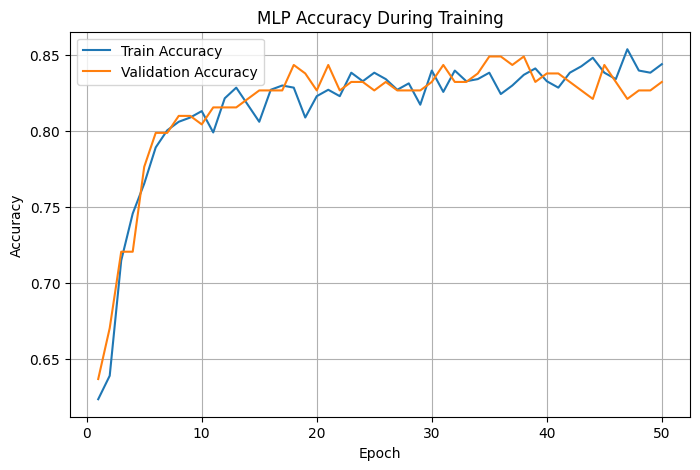

In [133]:
history_df = pd.DataFrame(history.history)
history_df["epoch"] = range(1, len(history_df) + 1)

history_df.head()

plt.figure(figsize=(8, 5))

sns.lineplot(data=history_df, x="epoch", y="accuracy", label="Train Accuracy")
sns.lineplot(data=history_df, x="epoch", y="val_accuracy", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy During Training")
plt.grid(True)
plt.show()

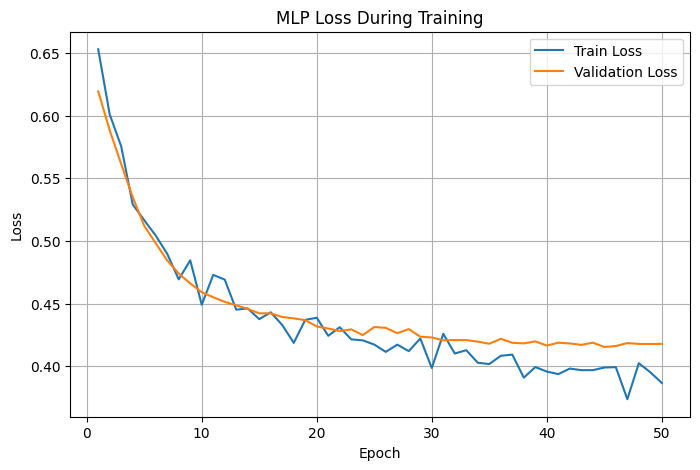

In [134]:
plt.figure(figsize=(8, 5))

sns.lineplot(data=history_df, x="epoch", y="loss", label="Train Loss")
sns.lineplot(data=history_df, x="epoch", y="val_loss", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Loss During Training")
plt.grid(True)
plt.show()

In [135]:
print("Validation Accuracy:", accuracy_score(y_valid_mlp, y_pred))
print("Validation F1:", f1_score(y_valid_mlp, y_pred))

print(classification_report(y_valid_mlp, y_pred))
print(confusion_matrix(y_valid_mlp, y_pred))

Validation Accuracy: 0.8324022346368715
Validation F1: 0.7580645161290323
              precision    recall  f1-score   support

           0       0.82      0.93      0.87       110
           1       0.85      0.68      0.76        69

    accuracy                           0.83       179
   macro avg       0.84      0.80      0.81       179
weighted avg       0.83      0.83      0.83       179

[[102   8]
 [ 22  47]]


| model_name                           | best_cv_f1 | best_cv_accuracy | valid_accuracy | valid_f1 |
| ------------------------------------ | ---------: | ---------------: | -------------: | -------: |
| Logistic Regression by median impute |   0.761438 |         0.823057 |       0.849162 | 0.793893 |
| Decision Tree by median impute       |   0.756929 |         0.824505 |       0.832402 | 0.776119 |
| Random Forest by median impute       |   0.768910 |         0.831478 |       0.821229 | 0.757576 |


### Сравнение качества с классическими ML моделями. 

В данном анализе сравниваются результаты MLP с результатами логистической регрессии, дерева решений и случайного леса с подставлением возраста медианным значением, так как в предыдущем анализе было выяснено, что поставление по полу и пассажирскому классу не улучшает качество работы вышеперечисленных алгоритмов. 

Без подбора гиперпараметров, MLP с двумя скрытыми слоями, по 32 и 16 нейронов соответственно, показывает данное качество на валидационной выборке: `Accuracy - 0.83`, `F1 - 0.76`. Через сравнение метрик, можно увидеть, что MLP в данном случае работает хуже, чем логистическая регрессия (`Accuracy - 0.85`, `F1 - 0.79`), но лучше, чем или одинаково с деревом решений и случайным лесом. 

По отчету классификации видно, что MLP лучше справляется с классом `0` — пассажиры, которые не выжили: recall для этого класса равен `0.93`. Однако модель хуже находит выживших пассажиров: для класса `1` recall составляет `0.68`. Это дальше подтверждается матрицей ошибок - модель ошибочно отнесла 22 пассажира к невыжившим. 